一、数据加载以及对数据的探索性分析

数据集形状: (5572, 2)

数据集前5行:
  label                                            message
0   ham  Go until jurong point, crazy.. Available only ...
1   ham                      Ok lar... Joking wif u oni...
2  spam  Free entry in 2 a wkly comp to win FA Cup fina...
3   ham  U dun say so early hor... U c already then say...
4   ham  Nah I don't think he goes to usf, he lives aro...

缺失值统计:
label      0
message    0
dtype: int64

类别分布:
label
ham     4825
spam     747
Name: count, dtype: int64

类别比例:
label
ham     0.865937
spam    0.134063
Name: proportion, dtype: float64

消息长度统计:
      message_length                                                           \
               count        mean        std   min    25%    50%    75%    max   
label                                                                           
ham           4825.0   71.558964  58.459702   2.0   33.0   52.0   93.0  910.0   
spam           747.0  139.119143  28.998900  13.0  133.0  149.0  158.0  224.0   

      word_co

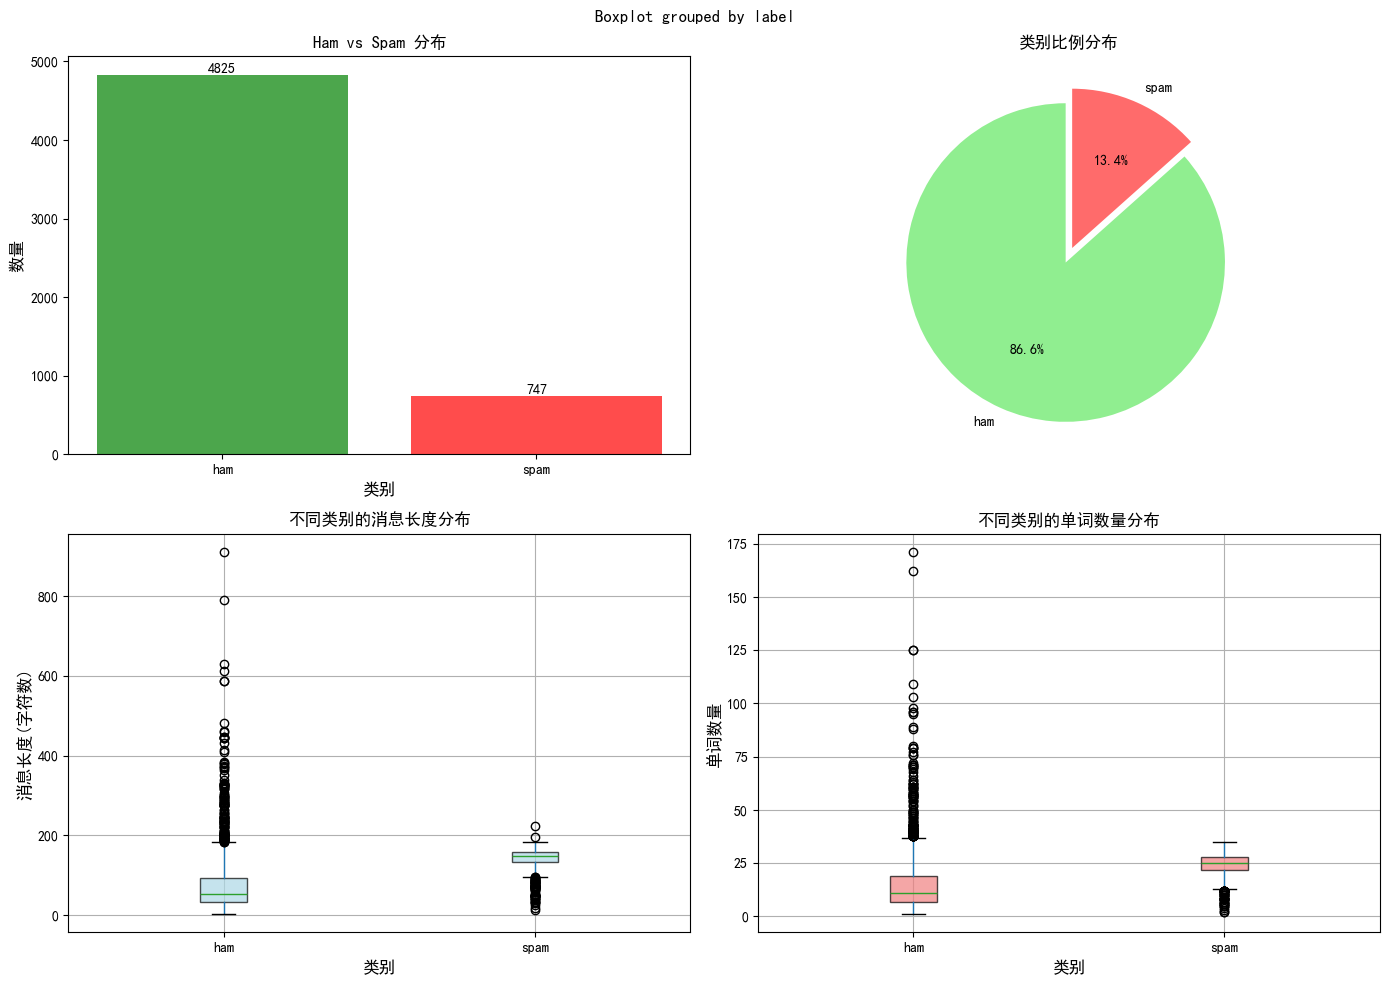

In [29]:
# 导入必要的库
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import (
    classification_report, 
    confusion_matrix, 
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
)
import warnings

warnings.filterwarnings('ignore')
plt.rcParams['font.sans-serif'] = ['SimHei', 'DejaVu Sans']
plt.rcParams['axes.unicode_minus'] = False
# 设置随机种子,确保结果可复现
np.random.seed(42)

# 数据加载
# 读取CSV文件
df = pd.read_csv(
    'SMSSpamCollection.csv', 
    sep='\t',  # tab分隔符
    header=None,  # 没有列名
    names=['label', 'message'],  # 手动指定列名:标签和消息内容
    encoding='latin-1'  # 编码方式
)

# 显示数据集基本信息
print(f"数据集形状: {df.shape}")
print(f"\n数据集前5行:")
print(df.head())

# 数据探索性分析
# 检查缺失值
print(f"\n缺失值统计:")
print(df.isnull().sum())

# 类别分布统计
print(f"\n类别分布:")
label_counts = df['label'].value_counts()
print(label_counts)
print(f"\n类别比例:")
print(df['label'].value_counts(normalize=True))

# 计算ham和spam的具体数量和比例
ham_count = label_counts['ham']
spam_count = label_counts['spam']
ham_ratio = ham_count / len(df) * 100
spam_ratio = spam_count / len(df) * 100

# 文本长度分析
# 计算每条消息的字符长度
df['message_length'] = df['message'].apply(len)

# 计算每条消息的单词数量
df['word_count'] = df['message'].apply(lambda x: len(x.split()))

print(f"\n消息长度统计:")
print(df.groupby('label')[['message_length', 'word_count']].describe())

# 3.数据可视化
# 创建一个包含多个子图的画布
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('垃圾邮件数据集探索性分析', fontsize=16, fontweight='bold')

# 子图1: 类别分布柱状图
axes[0, 0].bar(label_counts.index, label_counts.values, color=['green', 'red'], alpha=0.7)
axes[0, 0].set_xlabel('类别', fontsize=12)
axes[0, 0].set_ylabel('数量', fontsize=12)
axes[0, 0].set_title('Ham vs Spam 分布', fontsize=12, fontweight='bold')
# 在柱状图上添加数值标签
for i, (label, count) in enumerate(zip(label_counts.index, label_counts.values)):
    axes[0, 0].text(i, count, str(count), ha='center', va='bottom', fontsize=10)

# 子图2: 类别分布饼图
colors = ['#90EE90', '#FF6B6B']
axes[0, 1].pie(
    label_counts.values, 
    labels=label_counts.index, 
    autopct='%1.1f%%',  # 显示百分比
    startangle=90,  # 起始角度
    colors=colors,
    explode=(0.05, 0.05)  # 突出显示
)
axes[0, 1].set_title('类别比例分布', fontsize=12, fontweight='bold')

# 子图3: 消息长度分布箱线图
df.boxplot(
    column='message_length', 
    by='label', 
    ax=axes[1, 0],
    patch_artist=True,
    boxprops=dict(facecolor='lightblue', alpha=0.7)
)
axes[1, 0].set_xlabel('类别', fontsize=12)
axes[1, 0].set_ylabel('消息长度(字符数)', fontsize=12)
axes[1, 0].set_title('不同类别的消息长度分布', fontsize=12, fontweight='bold')
plt.sca(axes[1, 0])
plt.xticks([1, 2], ['ham', 'spam'])

# 子图4: 单词数量分布箱线图
df.boxplot(
    column='word_count', 
    by='label', 
    ax=axes[1, 1],
    patch_artist=True,
    boxprops=dict(facecolor='lightcoral', alpha=0.7)
)
axes[1, 1].set_xlabel('类别', fontsize=12)
axes[1, 1].set_ylabel('单词数量', fontsize=12)
axes[1, 1].set_title('不同类别的单词数量分布', fontsize=12, fontweight='bold')
plt.sca(axes[1, 1])
plt.xticks([1, 2], ['ham', 'spam'])

# 调整子图间距
plt.tight_layout()

# 保存图表到本地
plt.savefig('数据基本信息.png', dpi=300, bbox_inches='tight')
print("数据探索可视化已保存: 数据基本信息.png")
plt.show()

二、数据预处理

In [25]:
# 标签编码
# 将文本标签转换为数值
df['label_encoded'] = df['label'].map({'ham': 0, 'spam': 1})

print(f"\n编码后的标签分布:")
print(df['label_encoded'].value_counts().sort_index())

# 准备特征(X)和标签(y)
X = df['message']  # 消息文本内容
y = df['label_encoded']  # 编码后的标签

# 使用TF-IDF向量化器进行特征提取
vectorizer = TfidfVectorizer(
    max_features=3000,  # 最多保留3000个最重要的特征词
    min_df=2,  # 词语至少在2个文档中出现才会被保留
    max_df=0.8,  # 词语在超过80%的文档中出现则被忽略(太常见的词)
    stop_words='english',  # 移除英文停用词(如the, is, at等)
    lowercase=True,  # 将所有文本转为小写
    ngram_range=(1, 2)  # 使用1-gram和2-gram(单个词和两个词的组合)
)

# 对训练数据进行拟合和转换
X_tfidf = vectorizer.fit_transform(X)

print(f"TF-IDF特征矩阵形状: {X_tfidf.shape}")
print(f"提取的特征词数量: {len(vectorizer.get_feature_names_out())}")
print(f"\n前20个特征词:")
print(vectorizer.get_feature_names_out()[:20])

# 数据集划分
# 将数据集划分为训练集(80%)和测试集(20%)
X_train, X_test, y_train, y_test = train_test_split(
    X_tfidf,  # 特征矩阵
    y,  # 标签
    test_size=0.2,  # 测试集占20%
    stratify=y,  # 分层采样,保持类别比例
    random_state=42  # 随机种子
)

print(f"训练集大小: {X_train.shape[0]} 样本")
print(f"测试集大小: {X_test.shape[0]} 样本")
print(f"\n训练集类别分布:")
print(y_train.value_counts().sort_index())
print(f"\n测试集类别分布:")
print(y_test.value_counts().sort_index())


编码后的标签分布:
label_encoded
0    4825
1     747
Name: count, dtype: int64
TF-IDF特征矩阵形状: (5572, 3000)
提取的特征词数量: 3000

前20个特征词:
['00' '00 sub' '000' '000 bonus' '000 cash' '02' '03' '03 2nd' '04' '05'
 '06' '06 03' '0800' '0800 542' '08000839402' '08000839402 call2optout'
 '08000930705' '08000930705 delivery' '08001950382' '0870']
训练集大小: 4457 样本
测试集大小: 1115 样本

训练集类别分布:
label_encoded
0    3859
1     598
Name: count, dtype: int64

测试集类别分布:
label_encoded
0    966
1    149
Name: count, dtype: int64


三、构建多层感知机模型，训练并进行模型预测

Iteration 1, loss = 0.31968691
Validation score: 0.961883
Iteration 2, loss = 0.05211765
Validation score: 0.982063
Iteration 3, loss = 0.01906429
Validation score: 0.986547
Iteration 4, loss = 0.00934233
Validation score: 0.982063
Iteration 5, loss = 0.00623961
Validation score: 0.988789
Iteration 6, loss = 0.00454788
Validation score: 0.982063
Iteration 7, loss = 0.00356644
Validation score: 0.979821
Iteration 8, loss = 0.00324149
Validation score: 0.982063
Iteration 9, loss = 0.00297448
Validation score: 0.984305
Iteration 10, loss = 0.00283092
Validation score: 0.984305
Iteration 11, loss = 0.00273988
Validation score: 0.982063
Iteration 12, loss = 0.00264043
Validation score: 0.982063
Iteration 13, loss = 0.00256341
Validation score: 0.984305
Iteration 14, loss = 0.00270120
Validation score: 0.982063
Iteration 15, loss = 0.00250574
Validation score: 0.982063
Iteration 16, loss = 0.00252070
Validation score: 0.982063
Validation score did not improve more than tol=0.000100 for 10 co

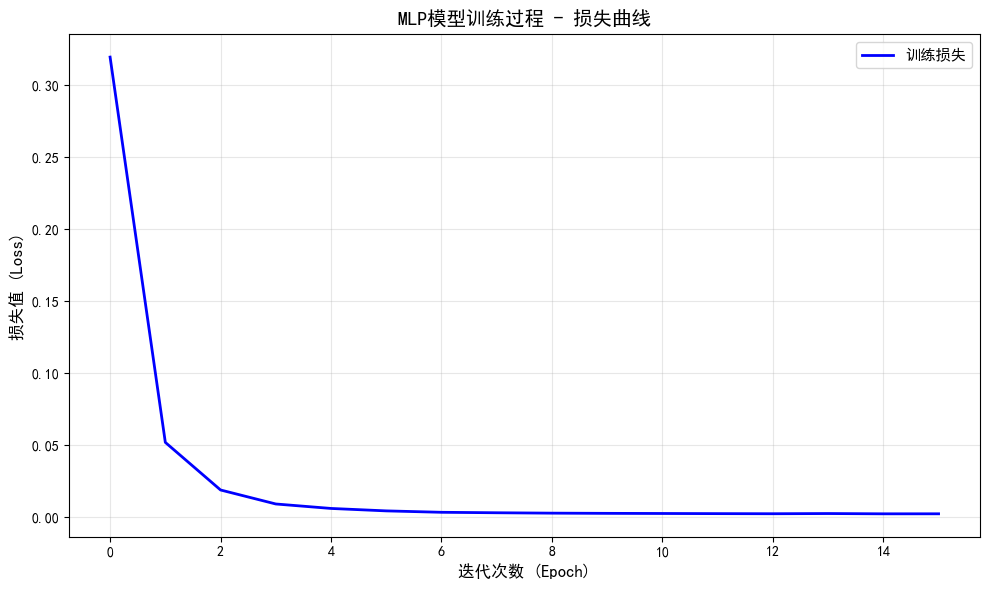

In [26]:
# 创建MLP分类器
mlp = MLPClassifier(
    hidden_layer_sizes=(100, 50),  # 两个隐藏层,第一层100个神经元,第二层50个神经元
    activation='relu',  # 激活函数使用ReLU
    solver='adam',  # 优化器使用Adam(自适应学习率)
    alpha=0.0001,  # L2正则化参数,防止过拟合
    batch_size=32,  # 每次更新权重使用32个样本
    learning_rate='adaptive',  # 自适应学习率
    learning_rate_init=0.001,  # 初始学习率
    max_iter=300,  # 最大迭代次数
    early_stopping=True,  # 启用早停,防止过拟合
    validation_fraction=0.1,  # 从训练集中取10%作为验证集
    n_iter_no_change=10,  # 验证集性能10次迭代没有改善则停止
    random_state=42,  # 随机种子
    verbose=True  # 显示训练过程
)

# 训练模型
mlp.fit(X_train, y_train)

print(f"实际迭代次数: {mlp.n_iter_}")
print(f"最终训练损失: {mlp.loss_:.6f}")

# 绘制损失曲线
plt.figure(figsize=(10, 6))
plt.plot(mlp.loss_curve_, linewidth=2, color='blue', label='训练损失')
plt.xlabel('迭代次数 (Epoch)', fontsize=12)
plt.ylabel('损失值 (Loss)', fontsize=12)
plt.title('MLP模型训练过程 - 损失曲线', fontsize=14, fontweight='bold')
plt.grid(True, alpha=0.3)
plt.legend(fontsize=11)
plt.tight_layout()

# 保存损失曲线图
plt.savefig('损失曲线.png', dpi=300, bbox_inches='tight')
print("损失曲线已保存: 损失曲线.png")
plt.show()

# 模型预测
# 在训练集上进行预测
y_train_pred = mlp.predict(X_train)
# 在测试集上进行预测
y_test_pred = mlp.predict(X_test)

四、模型性能评估


训练集性能:
  准确率 (Accuracy):  0.9982 (99.82%)
  精确率 (Precision): 0.9933 (99.33%)
  召回率 (Recall):    0.9933 (99.33%)
  F1分数 (F1-Score):  0.9933

测试集性能:
  准确率 (Accuracy):  0.9803 (98.03%)
  精确率 (Precision): 0.9441 (94.41%)
  召回率 (Recall):    0.9060 (90.60%)
  F1分数 (F1-Score):  0.9247

测试集详细分类报告:
------------------------------------------------------------
              precision    recall  f1-score   support

    Ham (正常)     0.9856    0.9917    0.9886       966
   Spam (垃圾)     0.9441    0.9060    0.9247       149

    accuracy                         0.9803      1115
   macro avg     0.9648    0.9489    0.9567      1115
weighted avg     0.9800    0.9803    0.9801      1115

混淆矩阵:
[[958   8]
 [ 14 135]]

混淆矩阵图已保存: 混淆矩阵图.png


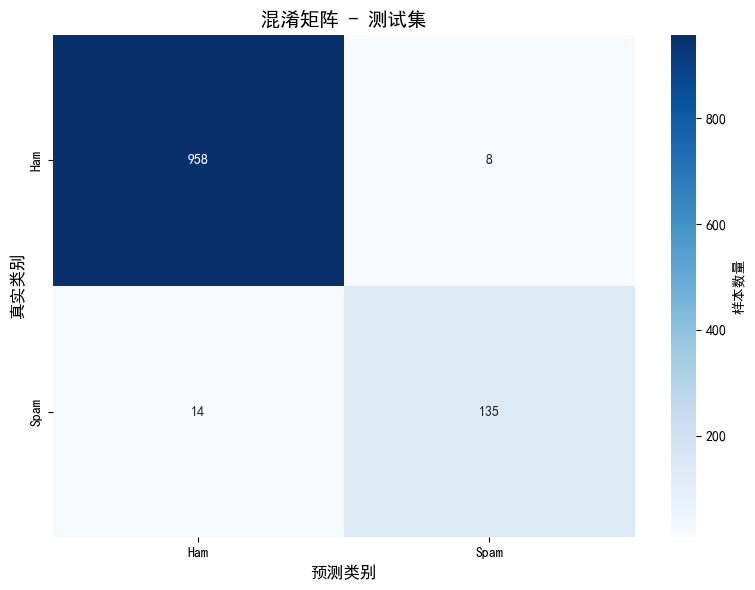

性能对比图已保存: 性能对比图.png


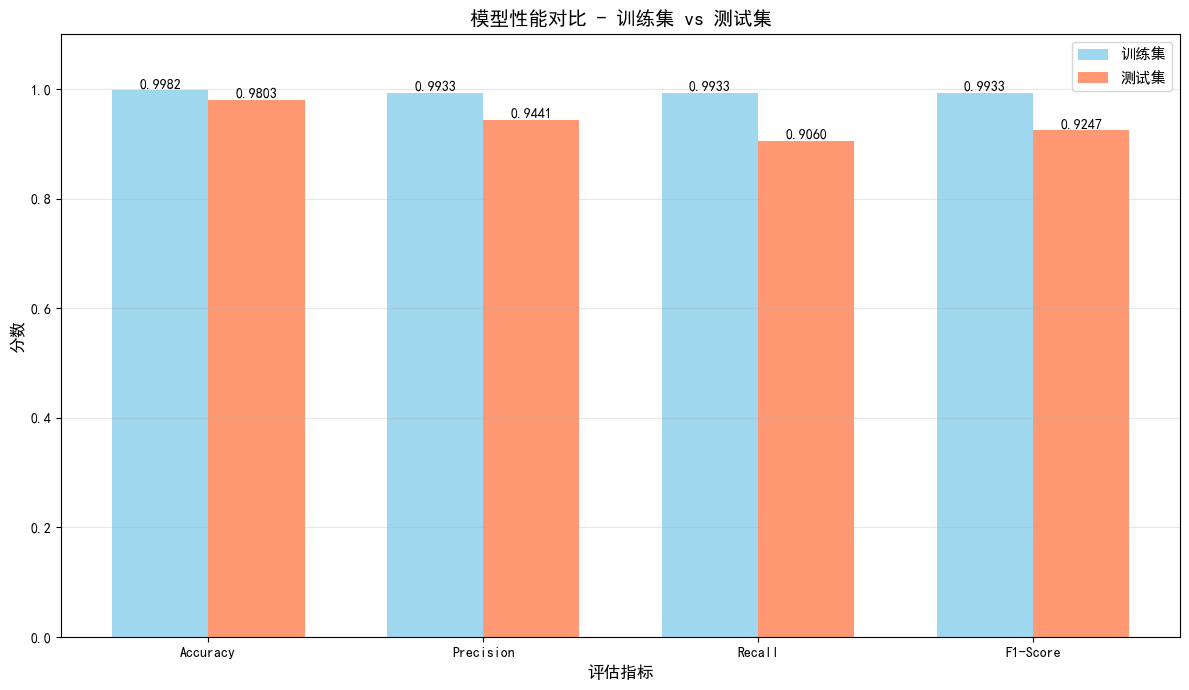

In [30]:
# 计算训练集性能指标
train_accuracy = accuracy_score(y_train, y_train_pred)
train_precision = precision_score(y_train, y_train_pred)
train_recall = recall_score(y_train, y_train_pred)
train_f1 = f1_score(y_train, y_train_pred)

# 计算测试集性能指标
test_accuracy = accuracy_score(y_test, y_test_pred)
test_precision = precision_score(y_test, y_test_pred)
test_recall = recall_score(y_test, y_test_pred)
test_f1 = f1_score(y_test, y_test_pred)

# 打印性能指标
print("\n训练集性能:")
print(f"  准确率 (Accuracy):  {train_accuracy:.4f} ({train_accuracy*100:.2f}%)")
print(f"  精确率 (Precision): {train_precision:.4f} ({train_precision*100:.2f}%)")
print(f"  召回率 (Recall):    {train_recall:.4f} ({train_recall*100:.2f}%)")
print(f"  F1分数 (F1-Score):  {train_f1:.4f}")

print("\n测试集性能:")
print(f"  准确率 (Accuracy):  {test_accuracy:.4f} ({test_accuracy*100:.2f}%)")
print(f"  精确率 (Precision): {test_precision:.4f} ({test_precision*100:.2f}%)")
print(f"  召回率 (Recall):    {test_recall:.4f} ({test_recall*100:.2f}%)")
print(f"  F1分数 (F1-Score):  {test_f1:.4f}")

# 详细的分类报告
print("\n测试集详细分类报告:")
print("-" * 60)
# target_names指定类别名称,使报告更易读
print(classification_report(
    y_test, 
    y_test_pred, 
    target_names=['Ham (正常)', 'Spam (垃圾)'],
    digits=4
))

# 计算混淆矩阵
cm = confusion_matrix(y_test, y_test_pred)

print("混淆矩阵:")
print(cm)

# 绘制混淆矩阵热力图
plt.figure(figsize=(8, 6))
sns.heatmap(
    cm, 
    annot=True,  # 显示数值
    fmt='d',  # 整数格式
    cmap='Blues',  # 颜色方案
    xticklabels=['Ham', 'Spam'],
    yticklabels=['Ham', 'Spam'],
    cbar_kws={'label': '样本数量'}
)
plt.xlabel('预测类别', fontsize=12, fontweight='bold')
plt.ylabel('真实类别', fontsize=12, fontweight='bold')
plt.title('混淆矩阵 - 测试集', fontsize=14, fontweight='bold')
plt.tight_layout()

# 保存混淆矩阵图
plt.savefig('混淆矩阵图.png', dpi=300, bbox_inches='tight')
print("\n混淆矩阵图已保存: 混淆矩阵图.png")
plt.show()

# 模型性能对比可视化
# 准备数据
metrics = ['Accuracy', 'Precision', 'Recall', 'F1-Score']
train_scores = [train_accuracy, train_precision, train_recall, train_f1]
test_scores = [test_accuracy, test_precision, test_recall, test_f1]

# 创建对比柱状图
x = np.arange(len(metrics))
width = 0.35

fig, ax = plt.subplots(figsize=(12, 7))
bars1 = ax.bar(x - width/2, train_scores, width, label='训练集', color='skyblue', alpha=0.8)
bars2 = ax.bar(x + width/2, test_scores, width, label='测试集', color='coral', alpha=0.8)

# 添加数值标签
for bars in [bars1, bars2]:
    for bar in bars:
        height = bar.get_height()
        ax.text(
            bar.get_x() + bar.get_width()/2., 
            height,
            f'{height:.4f}',
            ha='center', 
            va='bottom',
            fontsize=10
        )

ax.set_xlabel('评估指标', fontsize=12, fontweight='bold')
ax.set_ylabel('分数', fontsize=12, fontweight='bold')
ax.set_title('模型性能对比 - 训练集 vs 测试集', fontsize=14, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(metrics)
ax.legend(fontsize=11)
ax.set_ylim([0, 1.1])
ax.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.savefig('性能对比图.png', dpi=300, bbox_inches='tight')
print("性能对比图已保存: 性能对比图.png")
plt.show()